# Augmentation des données 

## 1. Téléchargement du csv et vérification du split 

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import os, time

# === A MODIFIER selon ton dossier ===
OUT_ROOT = Path(r"C:/Users/khodj\Documents/M2_ISI/PFE/data_clean")
META_DIR = OUT_ROOT / "meta"

# Si tu as déjà un fichier splits (recommandé)
SPLIT_CSV = META_DIR / "mindvoice_vision_splits.csv"

# Sinon, on prendra labels_vision.csv et on fera un split rapide
LABELS_CSV = META_DIR / "labels_vision.csv"

print("SPLIT_CSV exists:", SPLIT_CSV.exists())
print("LABELS_CSV exists:", LABELS_CSV.exists())

if SPLIT_CSV.exists():
    df = pd.read_csv(SPLIT_CSV)
else:
    df = pd.read_csv(LABELS_CSV)
    # Split rapide si absent
    rng = np.random.default_rng(42)
    idx = np.arange(len(df))
    rng.shuffle(idx)
    val_ratio = 0.15
    n_val = int(len(df) * val_ratio)
    df["split"] = "train"
    df.loc[idx[:n_val], "split"] = "val"

df["split"].value_counts()


SPLIT_CSV exists: True
LABELS_CSV exists: True


split
train    26352
val       4650
Name: count, dtype: int64

## 2. Création du dosser dde  sortie 

In [9]:
import cv2

AUG_DIR = OUT_ROOT / "images_aug"
AUG_DIR.mkdir(parents=True, exist_ok=True)

AUG_LOG = META_DIR / "augmentation_log.csv"
AUG_OUT_CSV = META_DIR / "mindvoice_vision_labels_aug.csv"

print("AUG_DIR:", AUG_DIR)


AUG_DIR: C:\Users\khodj\Documents\M2_ISI\PFE\data_clean\images_aug


## 3. Fonctions d’augmentation (rotation légère, shift/zoom léger, luminosité/contraste, bruit léger, blur léger, flip)

In [10]:
def clamp_uint8(img):
    return np.clip(img, 0, 255).astype(np.uint8)

def random_brightness_contrast(img, rng, brightness=0.12, contrast=0.12):
    # img uint8 BGR
    alpha = 1.0 + rng.uniform(-contrast, contrast)  # contrast
    beta = rng.uniform(-brightness, brightness) * 255  # brightness
    out = img.astype(np.float32) * alpha + beta
    return clamp_uint8(out)

def random_gaussian_noise(img, rng, sigma=8.0):
    noise = rng.normal(0, sigma, img.shape).astype(np.float32)
    out = img.astype(np.float32) + noise
    return clamp_uint8(out)

def random_blur(img, rng):
    # blur léger aléatoire
    k = rng.choice([0, 3, 5], p=[0.6, 0.3, 0.1])  # souvent rien
    if k == 0:
        return img
    return cv2.GaussianBlur(img, (k, k), 0)

def random_flip(img, rng, p=0.5):
    if rng.random() < p:
        return cv2.flip(img, 1)  # horizontal
    return img

def random_affine(img, rng, max_rot=10, max_trans=0.06, max_scale=0.08):
    h, w = img.shape[:2]
    angle = rng.uniform(-max_rot, max_rot)
    scale = 1.0 + rng.uniform(-max_scale, max_scale)
    tx = rng.uniform(-max_trans, max_trans) * w
    ty = rng.uniform(-max_trans, max_trans) * h
    
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
    M[0, 2] += tx
    M[1, 2] += ty
    
    out = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
    return out

def augment_one(img, rng):
    # Ordre réaliste: affine -> photométrique -> bruit/blur -> flip
    out = random_affine(img, rng)
    if rng.random() < 0.8:
        out = random_brightness_contrast(out, rng)
    if rng.random() < 0.35:
        out = random_gaussian_noise(out, rng, sigma=rng.uniform(3, 10))
    out = random_blur(out, rng)
    out = random_flip(out, rng, p=0.5)
    return out


## 4. Paramètres d’augmentation (combien d’images au final)

In [11]:
RANDOM_SEED = 123

# N_AUG_PER_IMAGE=1, tu doubles le train
N_AUG_PER_IMAGE = 3     # 1 ou 2 max au début
MAX_TRAIN = None        # ex: 5000 si tu veux tester vite

train_df = df[df["split"] == "train"].copy().reset_index(drop=True)

if MAX_TRAIN is not None:
    train_df = train_df.sample(n=min(MAX_TRAIN, len(train_df)), random_state=RANDOM_SEED).reset_index(drop=True)

len(train_df), train_df.head(2)


(26352,
                                    id  \
 0  affectnet_d214462e3e157f2d_0000000   
 1  affectnet_e4477cd8bd3767f5_0000001   
 
                                             out_path   emotion  split  
 0  C:\Users\khodj\Documents\M2_ISI\PFE\data_clean...  surprise  train  
 1  C:\Users\khodj\Documents\M2_ISI\PFE\data_clean...     anger  train  )

## 5. Générer & sauvegarder les images augmentées + créer le nouveau CSV

In [12]:
from tqdm import tqdm
import hashlib

def make_aug_id(base_id, k):
    # id stable
    return f"{base_id}_aug{k}"

def safe_read_bgr(path):
    img = cv2.imread(str(path))
    return img

rng = np.random.default_rng(RANDOM_SEED)

new_rows = []
log_rows = []

for i, row in tqdm(list(train_df.iterrows()), total=len(train_df)):
    src_path = Path(row["out_path"]) if "out_path" in row else Path(row["image_path"])
    if not src_path.exists():
        log_rows.append({"status":"fail", "reason":"missing_out_path", "src_path":str(src_path)})
        continue

    img = safe_read_bgr(src_path)
    if img is None:
        log_rows.append({"status":"fail", "reason":"imread_failed", "src_path":str(src_path)})
        continue

    base_id = row["id"] if "id" in row else src_path.stem
    emotion = row["emotion"] if "emotion" in row else "unknown"

    for k in range(1, N_AUG_PER_IMAGE + 1):
        aug_img = augment_one(img, rng)

        aug_id = make_aug_id(base_id, k)

        # nom de fichier unique (évite collisions)
        # hash court sur (aug_id + src_path)
        h = hashlib.md5((aug_id + str(src_path)).encode("utf-8")).hexdigest()[:10]
        out_name = f"{aug_id}_{h}.png"
        out_path = AUG_DIR / out_name

        ok = cv2.imwrite(str(out_path), aug_img)
        if not ok:
            log_rows.append({"status":"fail", "reason":"imwrite_failed", "src_path":str(src_path), "out_path":str(out_path)})
            continue

        # Nouveau sample: split train
        new_rows.append({
            "id": out_path.stem,
            "out_path": str(out_path),
            "emotion": emotion,
            "split": "train",
            "source": "augmented",
            "parent_id": base_id,
            "parent_path": str(src_path),
        })

log_df = pd.DataFrame(log_rows)
aug_df = pd.DataFrame(new_rows)

print("Augmentés créés:", len(aug_df))
print("Erreurs:", len(log_df))


100%|██████████| 26352/26352 [05:14<00:00, 83.79it/s]

Augmentés créés: 79056
Erreurs: 0


## 6. Produire le CSV final “original + augmented”

In [13]:
# On garde les originaux tels quels
base_cols = ["id", "out_path", "emotion", "split"]
df_base = df.copy()

# Assurer colonnes
for c in base_cols:
    if c not in df_base.columns:
        raise ValueError(f"Colonne manquante dans df: {c}")

df_base = df_base[base_cols].copy()
df_base["source"] = "original"
df_base["parent_id"] = ""
df_base["parent_path"] = ""

# Concat
df_final = pd.concat([df_base, aug_df[["id","out_path","emotion","split","source","parent_id","parent_path"]]], ignore_index=True)

# Sauvegarde
df_final.to_csv(AUG_OUT_CSV, index=False)
print("✅ CSV final avec augmentation:", AUG_OUT_CSV)
df_final["source"].value_counts(), df_final["split"].value_counts()


✅ CSV final avec augmentation: C:\Users\khodj\Documents\M2_ISI\PFE\data_clean\meta\mindvoice_vision_labels_aug.csv


(source
 augmented    79056
 original     31002
 Name: count, dtype: int64,
 split
 train    105408
 val        4650
 Name: count, dtype: int64)

## 7. Vérification de la qualité

Fichiers manquants: 0
emotion
surprise    16592
happy       14820
anger       14228
disgust     12836
fear        12788
contempt    12360
sad         11416
neutral     10368
Name: count, dtype: int64


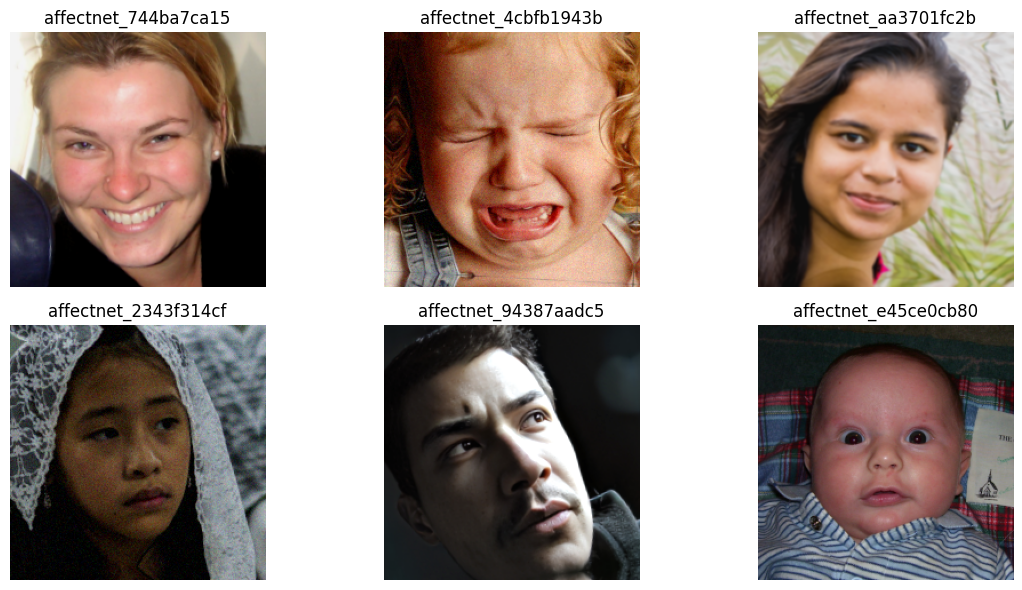

In [14]:
# 1) Vérifier que tout existe
missing = df_final[~df_final["out_path"].apply(lambda s: Path(s).exists())]
print("Fichiers manquants:", len(missing))

# 2) Distribution émotions (train uniquement)
train_final = df_final[df_final["split"] == "train"]
print(train_final["emotion"].value_counts().head(20))

# 3) Quelques exemples visuels (si tu veux)
import random
import matplotlib.pyplot as plt

sample_paths = train_final.sample(n=6, random_state=1)["out_path"].tolist()
plt.figure(figsize=(12,6))
for i, p in enumerate(sample_paths, 1):
    img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    plt.subplot(2,3,i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(Path(p).name[:20])
plt.tight_layout()
plt.show()
